In [45]:
#Importa bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings, requests, zipfile, io

#Ignora Warnings
warnings.filterwarnings("ignore")

#Importa função pra ler extensões arff
from scipy.io import arff

In [2]:
##Baixando arquivos dataset
arquivo_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00212/vertebral_column_data.zip"

r = requests.get(arquivo_url, stream=True)

arquivo_zip = zipfile.ZipFile(io.BytesIO(r.content))

arquivo_zip.extractall()

In [3]:
#Lendo Arquivo
data = arff.loadarff('column_2C_weka.arff')

#Criando DataFrame
df = pd.DataFrame(data[0])

df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,b'Abnormal'
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,b'Abnormal'
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,b'Abnormal'
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,b'Abnormal'
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,b'Abnormal'


In [4]:
#Qtd de Linhas e Colunas
df.shape

(310, 7)

In [5]:
#Listar Colunas
df.columns

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class'],
      dtype='object')

In [6]:
#Verifica Tipagem das colunas
df.dtypes

,0
pelvic_incidence,float64
pelvic_tilt,float64
lumbar_lordosis_angle,float64
sacral_slope,float64
pelvic_radius,float64
degree_spondylolisthesis,float64
class,object


In [7]:
#Exibe Estatísticas
df['pelvic_incidence'].describe()

,pelvic_incidence
count,310.000000
mean,60.496653
std,17.236520
min,26.147921
25%,46.430294
50%,58.691038
75%,72.877696
max,129.834041


In [8]:
#Exibe estatísticas por componente
df.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


<Axes: >

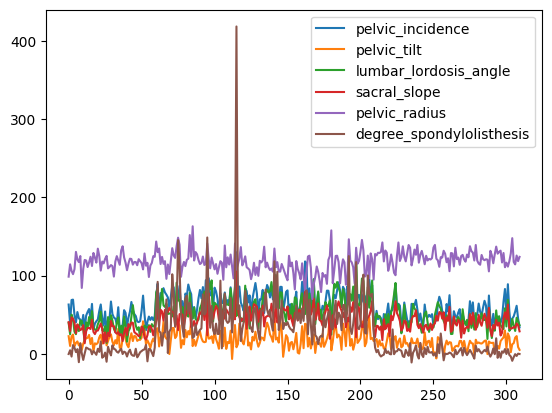

In [11]:
%matplotlib inline

df.plot()

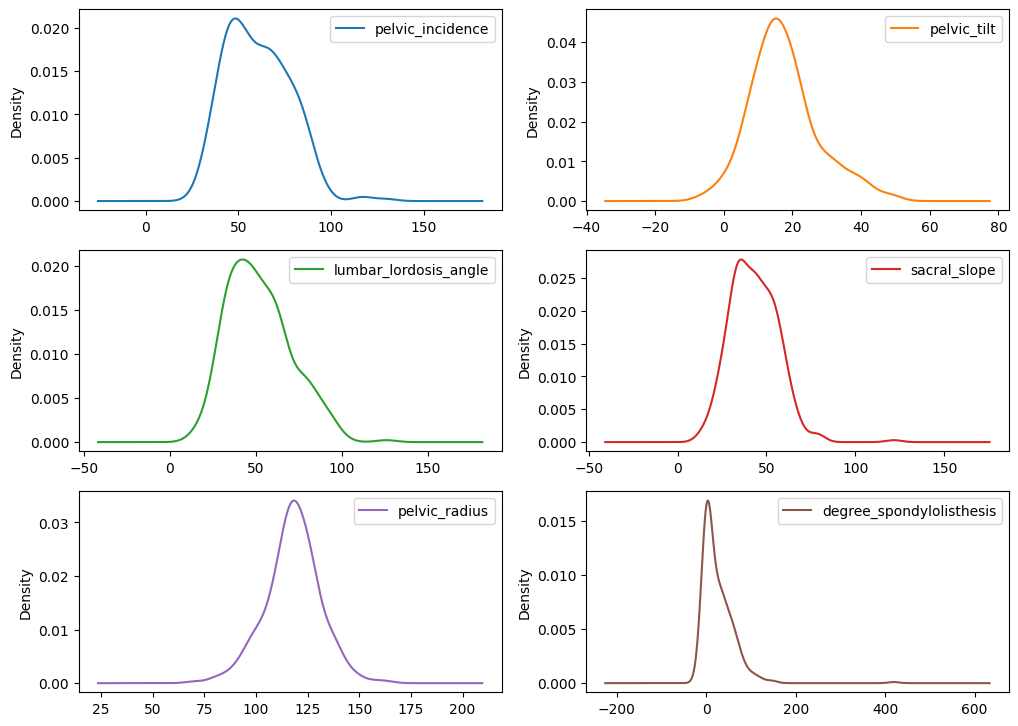

In [14]:
df.plot(kind='density', subplots=True, layout=(4,2), figsize=(12,12), sharex=False, sharey=False)

plt.show()

<Axes: ylabel='Density'>

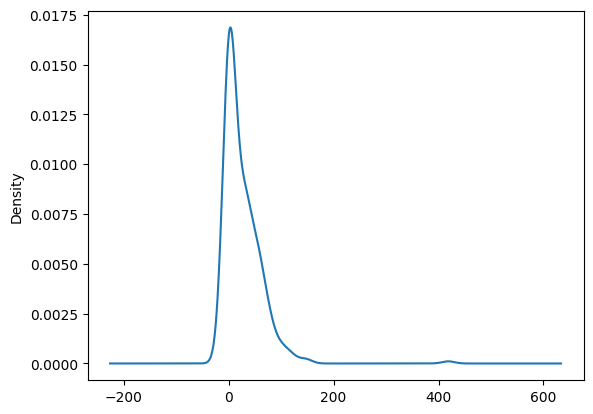

In [15]:
df['degree_spondylolisthesis'].plot.density()

<Axes: ylabel='Frequency'>

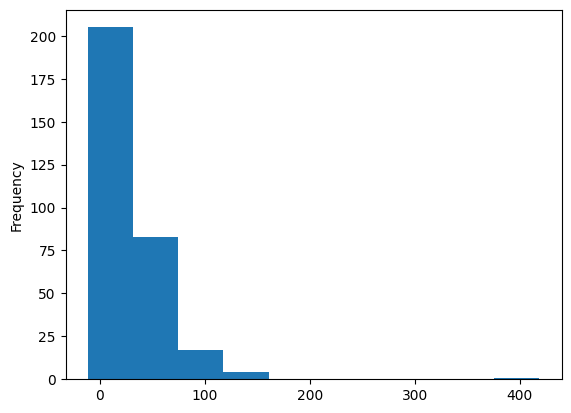

In [16]:
df['degree_spondylolisthesis'].plot.hist()

<Axes: >

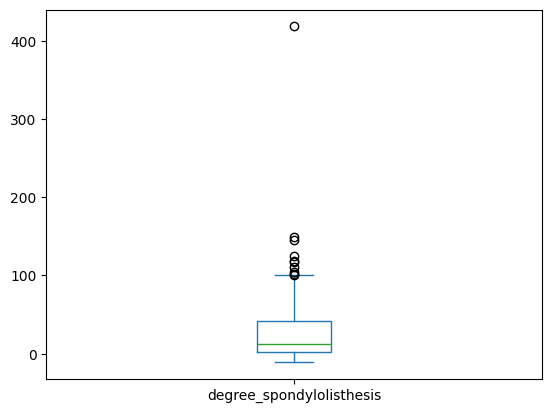

In [17]:
df['degree_spondylolisthesis'].plot.box()

In [20]:
df["class"].value_counts()

,count
class,
b'Abnormal',210
b'Normal',100


In [24]:
class_mapper = {b'Abnormal': 1, b'Normal': 0}

df["Class"] = df["class"].replace(class_mapper)

<Axes: xlabel='class', ylabel='degree_spondylolisthesis'>

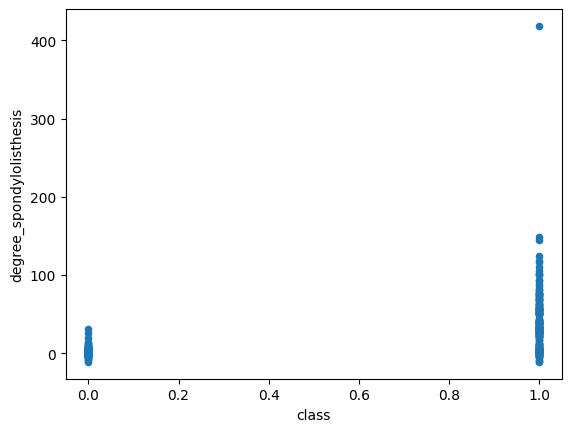

In [29]:
df.plot.scatter(y='degree_spondylolisthesis', x='class')

,0
0,"Axes(0.1,0.15;0.363636x0.75)"
1,"Axes(0.536364,0.15;0.363636x0.75)"


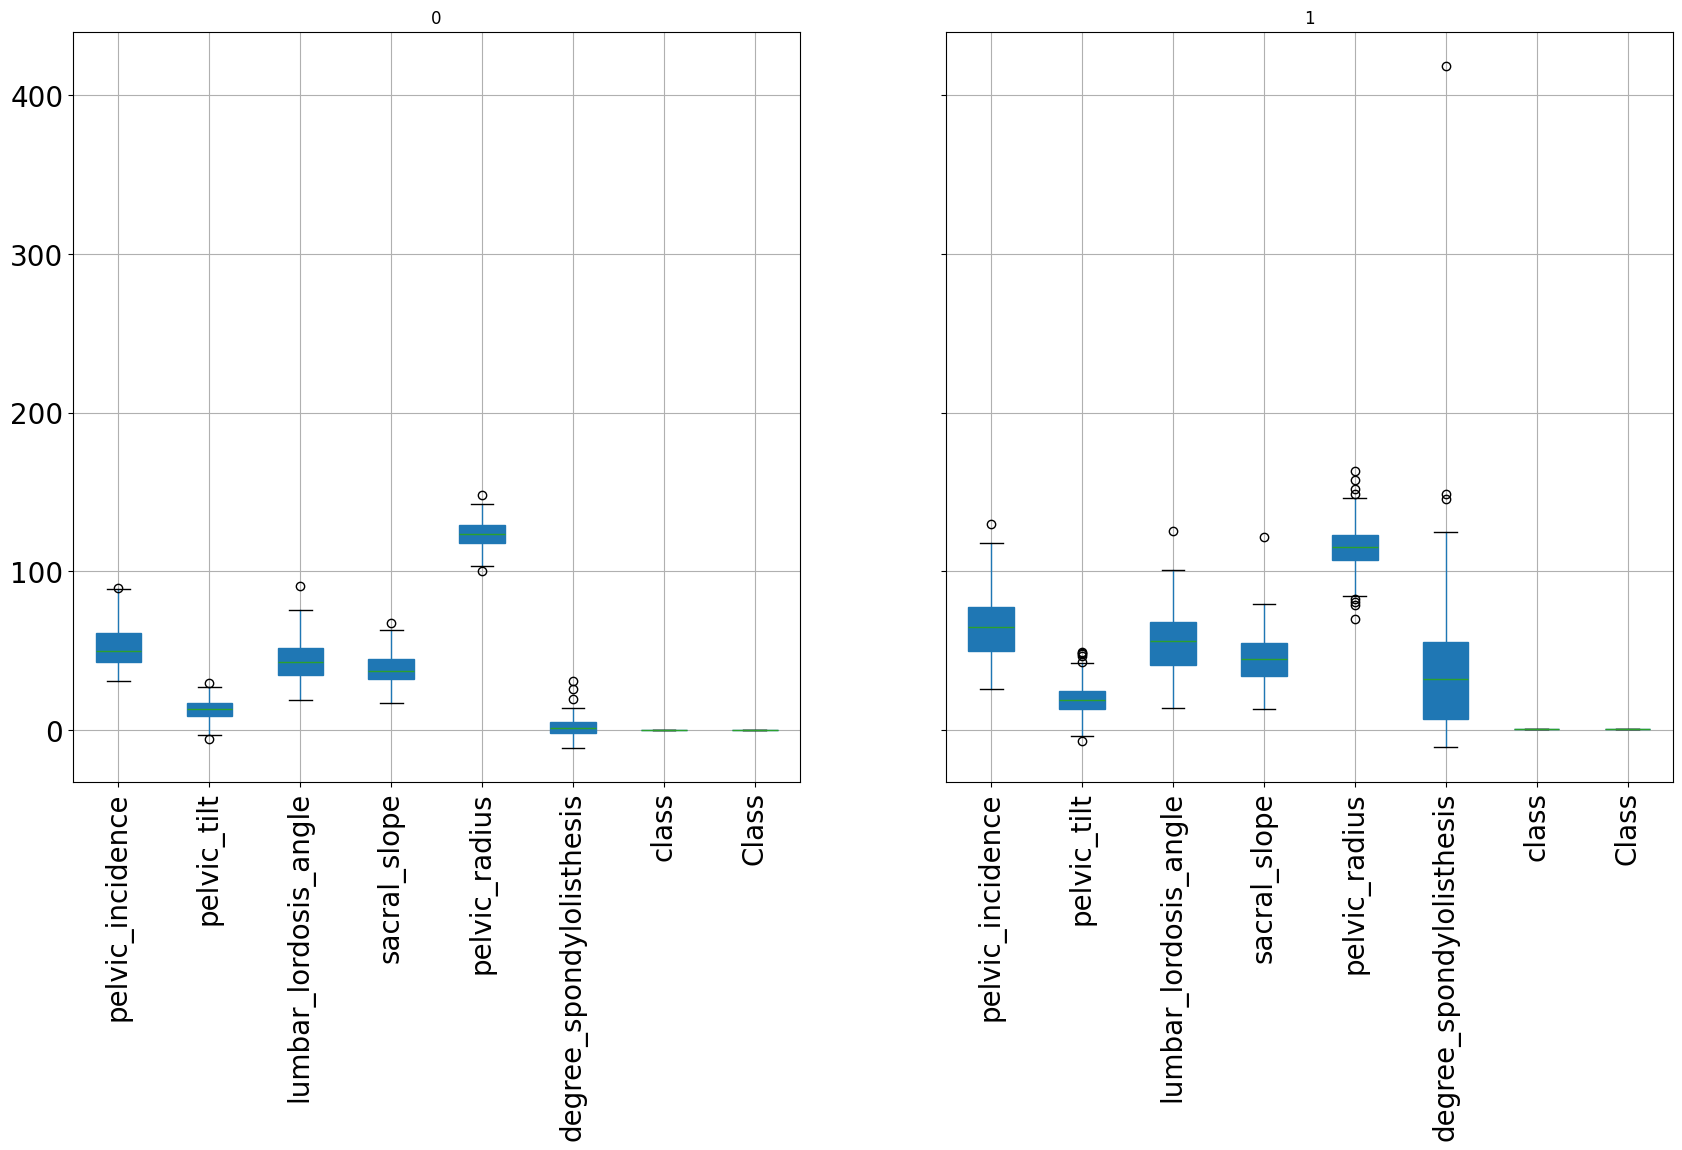

In [37]:
df.groupby("class").boxplot(
    fontsize=20,
    rot=90,
    figsize=(20,10),
    patch_artist=True
  )

In [38]:
matrix_info = df.corr(numeric_only=True)
matrix_info['Class'].sort_values(ascending=False)

,Class
class,1.000000
Class,1.000000
degree_spondylolisthesis,0.443687
pelvic_incidence,0.353336
pelvic_tilt,0.326063
lumbar_lordosis_angle,0.312484
sacral_slope,0.210602
pelvic_radius,-0.309857


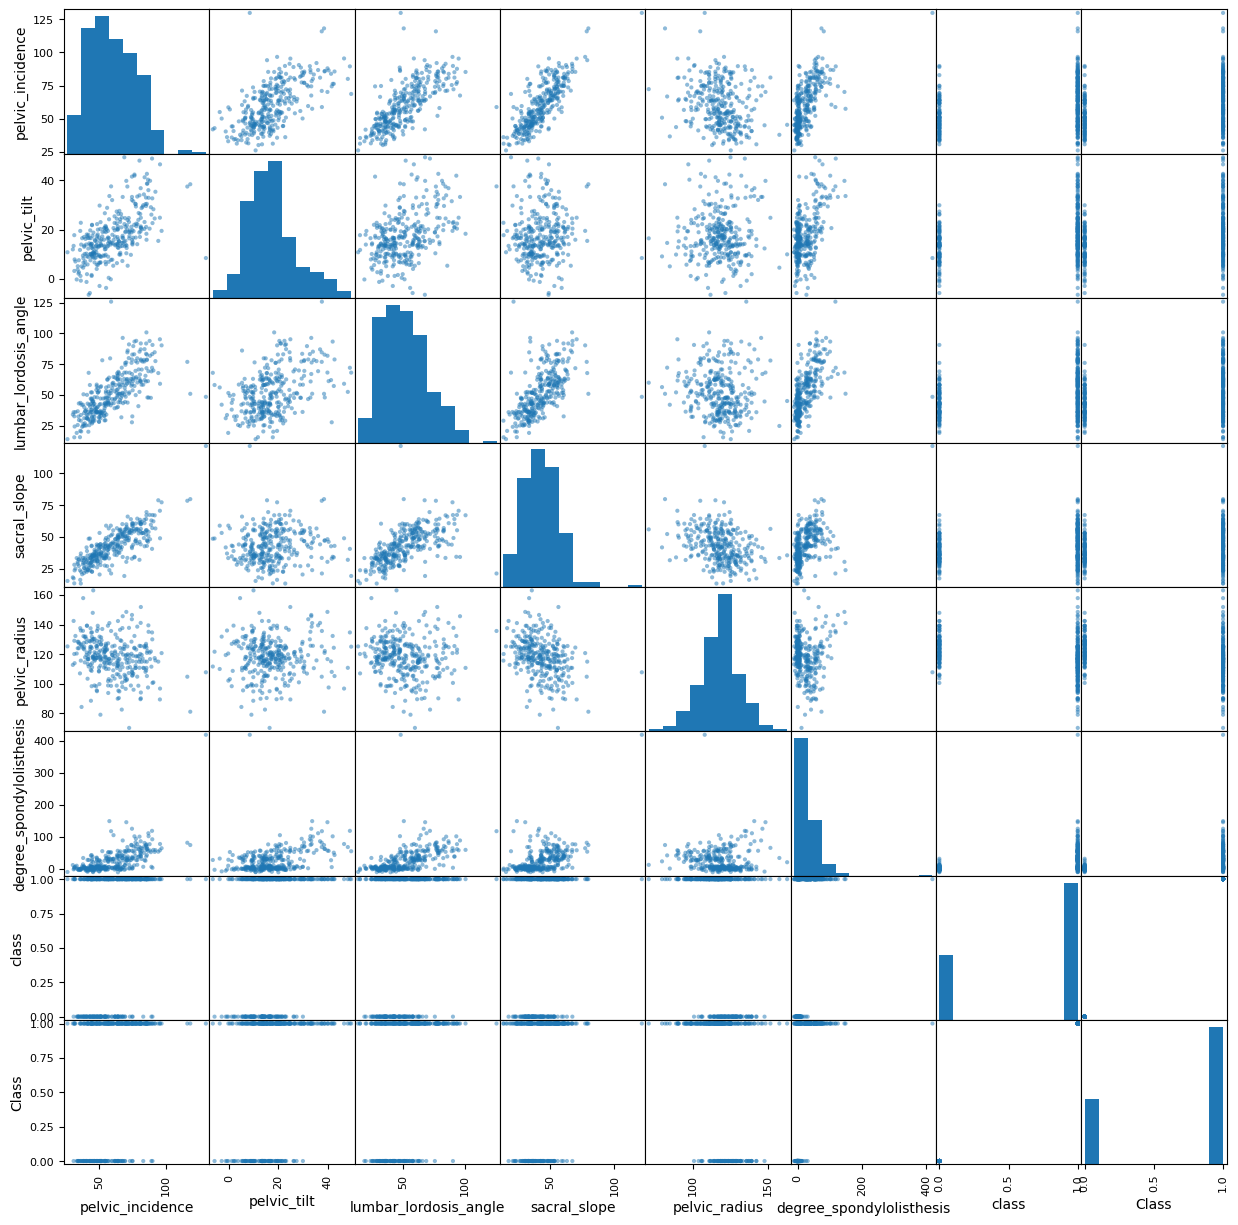

In [39]:
pd.plotting.scatter_matrix(df, figsize=(15,15))
plt.show()

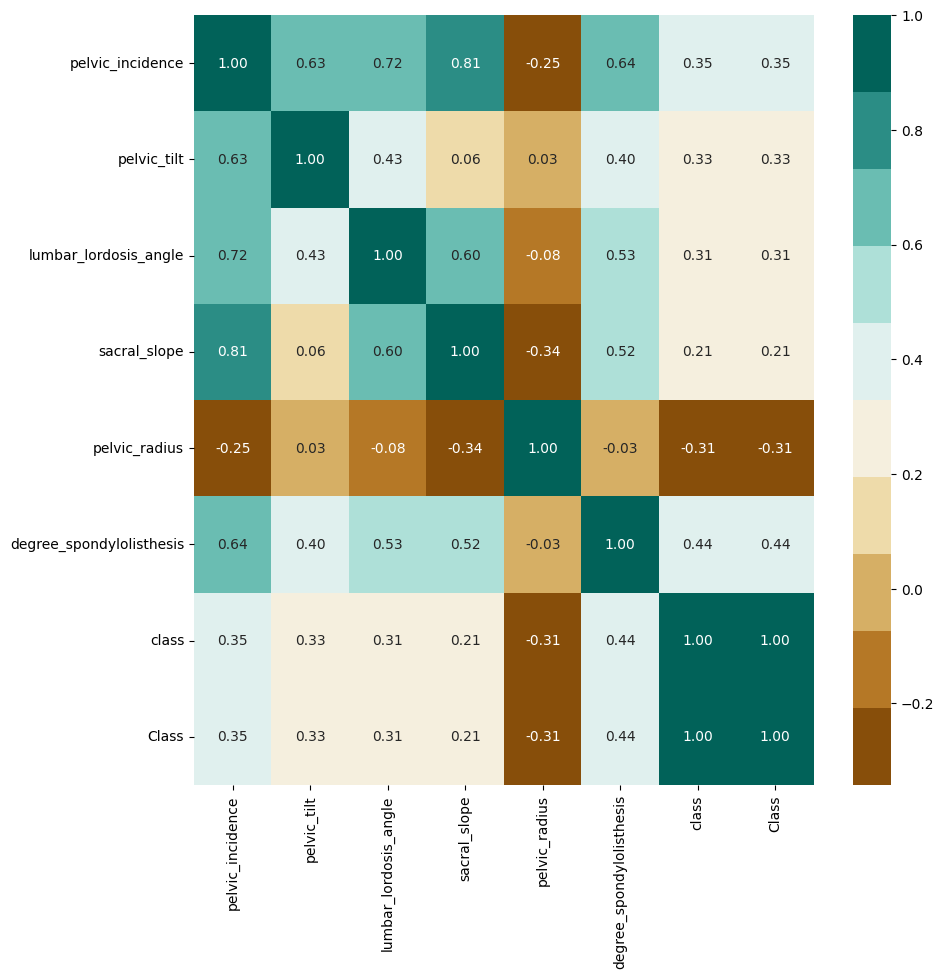

In [48]:
fig, ax = plt.subplots(figsize=(10,10))
colormap = sns.color_palette("BrBG", 10)
sns.heatmap(matrix_info, cmap=colormap, annot=True, fmt=".2f")
plt.show()